# Pipeline

## Imports

In [1]:
!pip install pymongo certifi
!pip install python-dotenv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pymongo import MongoClient
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import logging
from pymongo.errors import ConnectionFailure, OperationFailure
from dotenv import load_dotenv
import os

logging.basicConfig(
    filename="pipeline.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)
logger.info("Pipeline started")

load_dotenv()  # Load environment variables from .env file

MONGO_URI = os.getenv("MONGO_URI")

if not MONGO_URI:
    logger.error("MONGO_URI not found in environment variables")
    raise ValueError("MONGO_URI not found in environment variables")

## Query MongoDB into Dataframe

In [4]:
try:
    client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
    client.admin.command("ping")
    collection = client["air_quality_db"]["daily_aqi"]
    logger.info("Connected to MongoDB Atlas")
except ConnectionFailure as e:
    logger.error(f"MongoDB connection failed: {e}")
    raise

try: 
    cursor = collection.find({},{
        "_id": 0,
        "city": 1,
        "date": 1,
        "pollutant": 1,
        "aqi": 1, 
        "observation_count": 1,
        "observation_percent": 1,
    })

    df = pd.DataFrame(list(cursor))
    logger.info(f"Data loaded successfully with {len(df)} records")
except OperationFailure as e:
    logger.error(f"Data retrieval failed: {e}")
    raise

# Flatten nested subdocuments
try: 
    df["aqi_value"] = df["aqi"].apply(lambda x: x.get("value"))
    df["aqi_category"] = df["aqi"].apply(lambda x: x.get("category"))
    df["pm25_mean"] = df["pollutant"].apply(lambda x: x.get("mean") if isinstance(x, dict) else None)
    df["pm25_max"]  = df["pollutant"].apply(lambda x: x.get("max_value") if isinstance(x, dict) else None)
    df["max_hour"]  = df["pollutant"].apply(lambda x: x.get("max_hour") if isinstance(x, dict) else None)
    df = df.drop(columns=["pollutant", "aqi"])
    logger.info("Data flattened successfully")
except KeyError as e:
    logger.error(f"Data flattening failed: {e}")
    raise

# Parse date and extract temporal features
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["dow"] = df["date"].dt.dayofweek # 0=Monday, 6=Sunday
df["year"] = df["date"].dt.year
n_bad_dates = df["date"].isna().sum()
if n_bad_dates > 0:
    logger.warning(f"{n_bad_dates} records have invalid dates and will be dropped")
    df = df.dropna(subset=["date"])

print(f"Total documents loaded: {len(df)}")
print(f"\nAQI category distribution:\n{df['aqi_category'].value_counts()}")
df.head()

Total documents loaded: 493616

AQI category distribution:
aqi_category
Good                              245664
Moderate                          199644
Unknown                            46380
Unhealthy for Sensitive Groups      1240
Unhealthy                            528
Very Unhealthy                       160
Name: count, dtype: int64


,city,date,observation_count,observation_percent,aqi_value,aqi_category,pm25_mean,pm25_max,max_hour,month,dow,year
0,Los Angeles,2022-01-03,24,100.0,NaN,Unknown,8.5,28.0,0,1,0,2022
1,Los Angeles,2022-01-04,1,100.0,11.0,Good,1.9,1.9,0,1,1,2022
2,Los Angeles,2022-01-05,1,100.0,23.0,Good,4.2,4.2,0,1,2,2022
3,Los Angeles,2022-01-07,1,100.0,37.0,Good,6.6,6.6,0,1,4,2022
4,Los Angeles,2022-01-08,1,100.0,22.0,Good,4.0,4.0,0,1,5,2022


## Data Preparation and Quality Filtering

In [5]:
try: 
    def pm25_to_aqi(pm25):
        """
        Convert PM2.5 concentration to AQI value using EPA breakpoints
        """
        if pm25 is None or pd.isna(pm25) or pm25 < 0:
            return None
        breakpoints = [
            (0.0, 12.0, 0, 50),
            (12.1, 35.4, 51, 100),
            (35.5, 55.4, 101, 150),
            (55.5, 150.4, 151, 200),
            (150.5, 250.4, 201, 300),
            (250.5, 500.4, 301, 500),
        ]
        for c_low, c_high, aqi_low, aqi_high in breakpoints:
            if c_low <= pm25 <= c_high:
                return round(((aqi_high - aqi_low) / (c_high - c_low)) * (pm25 - c_low) + aqi_low)
        return 500
    
    # Recalculate category based on mean AQI value
    def aqi_category(aqi):
        if aqi is None or pd.isna(aqi):
            return None
        if aqi <= 50:
            return "Good"
        elif aqi <= 100:
            return "Moderate"
        elif aqi <= 150:
            return "Unhealthy for Sensitive Groups"
        elif aqi <= 200:
            return "Unhealthy"
        elif aqi <= 300:
            return "Very Unhealthy"
        else:
            return "Hazardous" 
        
    df["aqi_value"] = df["pm25_mean"].apply(pm25_to_aqi)
    df["aqi_category"] = df["aqi_value"].apply(aqi_category)
    logger.info("AQI values and categories recalculated successfully")

    n_before = len(df)
    # Apply EPA completeness filter
    df = df[df["observation_percent"] >= 75].copy()
    logger.info(f"Applied EPA completeness filter: {n_before - len(df)} records dropped, {len(df)} remaining")

    # Drop rows missing the target or key features
    n_before = len(df)
    df = df.dropna(subset=["aqi_value", "aqi_category", "pm25_mean", "pm25_max"])
    logger.info(f"Dropped records with missing key features: {n_before - len(df)} records dropped, {len(df)} remaining")

    n_before = len(df)
    # Deduplicate to one observation per city-date
    df = (
        df.groupby(["city", "date"], as_index=False)
        .agg({
            "pm25_mean": "mean", 
            "pm25_max": "max",
            "max_hour": "mean",
            "aqi_value": "mean",
            "aqi_category": "first",
            "month": "first",
            "dow": "first",
            "year": "first",
            "observation_percent": "mean",
        })
    )
    logger.info(f"Deduplicated to one observation per city-date: {n_before - len(df)} records dropped, {len(df)} remaining")
        
    df["aqi_category"] = df["aqi_value"].apply(aqi_category)

    print(f"Final dataset shape: {df.shape}")
    print(f"\nFinal AQI category distribution:\n{df['aqi_category'].value_counts()}")
except Exception as e:
    logger.error(f"Data preparation failed: {e}")
    raise

Final dataset shape: (3162, 11)

Final AQI category distribution:
aqi_category
Good                              2523
Moderate                           628
Unhealthy for Sensitive Groups       8
Unhealthy                            3
Name: count, dtype: int64


## Feature Engineering and Train/Test Split

In [6]:
try:
    # Sort by city and date so lag features look backwards in time 
    df = df.sort_values(["city", "date"]).reset_index(drop=True)

    # Create lag features
    df["pm25_mean_lag1"] = df.groupby("city")["pm25_mean"].shift(1)
    df["pm25_max_lag1"]  = df.groupby("city")["pm25_max"].shift(1)
    df["aqi_lag1"]       = df.groupby("city")["aqi_value"].shift(1)

    # Rolling averages over past 3 and 7 days 
    df["pm25_rolling3"] = df.groupby("city")["pm25_mean"].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
    df["pm25_rolling7"] = df.groupby("city")["pm25_mean"].transform(
        lambda x: x.shift(1).rolling(7, min_periods=1).mean()
    )

    # Drop rows where lag features are NaN (first day per city has no yesterday)
    n_before = len(df)
    df = df.dropna(subset=["pm25_mean_lag1", "pm25_max_lag1", "aqi_lag1"])
    logger.info(f"Dropped {n_before - len(df)} rows with no lag data, {len(df)} remaining")

    # Encode city
    df = pd.get_dummies(df, columns=["city"], drop_first=True)
    logger.info(f"Encoded city as dummy variables. New shape: {df.shape}")

    # Merge rare categories into "Unhealthy+" to simplify classification and address class imbalance
    def merge_rare(cat):
        if cat in ["Unhealthy for Sensitive Groups", "Unhealthy", "Very Unhealthy", "Hazardous"]:
            return "Unhealthy+"
        return cat

    df["aqi_category"] = df["aqi_category"].apply(merge_rare)
    logger.info(f"Merged rare AQI categories. Distribution:\n{df['aqi_category'].value_counts().to_dict()}")

    # pm25_mean and pm25_max are removed — those are same-day measurements
    features = [
        "pm25_mean_lag1",
        "pm25_max_lag1",
        "aqi_lag1",
        "pm25_rolling3",
        "pm25_rolling7",
        "max_hour",
        "month",
        "dow",
        "year",
    ] + [c for c in df.columns if c.startswith("city_")]

    target = "aqi_category"

    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    logger.info(f"Train/test split complete. Train: {len(X_train)}, Test: {len(X_test)}")
    print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")
    print(f"\nTarget distribution:\n{y.value_counts()}")

except Exception as e:
    logger.error(f"Feature engineering / data splitting failed: {e}")
    raise

Training set shape: (2525, 13), Test set shape: (632, 13)

Target distribution:
aqi_category
Good          2520
Moderate       626
Unhealthy+      11
Name: count, dtype: int64


## Random Forest Classifier

In [7]:
try: 
    rf = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

    rf.fit(X_train, y_train)
    logger.info("Random Forest model trained successfully")

    # Cross-validation
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="accuracy")
    logger.info(f"Cross-validation completed: mean accuracy={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")
    print(f"Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Test set evaluation
    y_pred = rf.predict(X_test)
    print("\nTest set accuracy:", rf.score(X_test, y_test))
    logger.info(f"Test set accuracy: {rf.score(X_test, y_test):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    logger.info("Model evaluation on test set completed")
except Exception as e:
    logger.error(f"Model training or evaluation failed: {e}")
    raise

Cross-validation accuracy: 0.8297 ± 0.0104

Test set accuracy: 0.8006329113924051

Classification Report:
               precision    recall  f1-score   support

        Good       0.89      0.86      0.87       505
    Moderate       0.50      0.58      0.54       125
  Unhealthy+       0.00      0.00      0.00         2

    accuracy                           0.80       632
   macro avg       0.46      0.48      0.47       632
weighted avg       0.81      0.80      0.81       632



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Analysis Rationale

### Random Forest
Across the literature that studied ML algorithms on AQI prediction tasks, Random Forest consistently performed the best. Specific reasons include: 

1. **Handles class imbalance** that up-weights the rare Unhealthy+ class so the model does not simply predict Good for every record
2. **Interpretable** with feature importances, allowing us to verify the model is learning meaningful patterns rather than memorizing the data
3. **Robust to overfitting** through 300 trees that is trained on a random subset of data, reducing variance compared to a single decision tree

### Lag Features
The problem statement is about predictive forecast, which is information the user needs before they step outside. Same-day PM2.5 measurements are not available the night before, so using them as features would make the model undeployable in practice. Lag features  (yesterday's mean, max, and AQI) plus 3-day and 7-day rolling averages represent everything knowable at prediction time, making this an actual forecast.

### Rare classes into Unhealthy+
The dataset contains only 11 records across Unhealthy for Sensitive Groups, Unhealthy, and Hazardous categories combined, which is too few for reliable evaluation. Merging them into a single Unhealthy+ class preserves the health risk signal while ensuring the class appears in both train and test splits. 

## Confusion Matrix

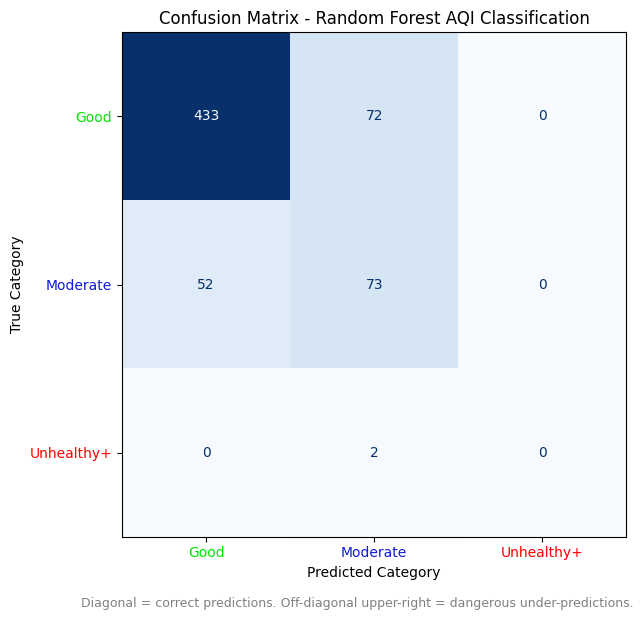

In [8]:
try:
    cat_order = ["Good", "Moderate", "Unhealthy+"]

    cat_order = [cat for cat in cat_order if cat in y_test.unique()]

    aqi_colors = {
        "Good": "#00e400",
        "Moderate": "#0f19df",
        "Unhealthy+": "#ff0000",
    }

    cm = confusion_matrix(y_test, y_pred, labels=cat_order)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cat_order)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)

    # Color the tick labels to match EPA AQI colors
    for tick, label in zip(ax.get_xticklabels(), cat_order):
        tick.set_color(aqi_colors.get(label, "black"))
    for tick, label in zip(ax.get_yticklabels(), cat_order):
        tick.set_color(aqi_colors.get(label, "black"))
                    
    plt.title("Confusion Matrix - Random Forest AQI Classification")
    plt.xlabel("Predicted Category")
    plt.ylabel("True Category")

    fig.text(0.5, -0.02,
        "Diagonal = correct predictions. Off-diagonal upper-right = dangerous under-predictions.",
        ha="center", fontsize=9, color="gray"
    )

    plt.tight_layout()
    plt.show()
    logger.info("Confusion matrix plotted successfully")
except Exception as e:
    logger.error(f"Confusion matrix plotting failed: {e}")
    raise

## Visualization Rationale

The confusion matrix was chosen as the primary results visualization for two reasons:

1. **Accuracy alone is misleading with class imbalance.** A model that predicts Good for every record would achieve accuracy of around 80% given the distribution of this dataset. The confusion matrix reveals whether the model is actually learning to distinguish Moderate and Unhealthy+ days or just defaulting to the majority class.

2. **Error direction matters for public health.** A model that confuses Good with Moderate is far less dangerous than one that confuses Unhealthy+ with Good. The matrix ordered from least to most severe makes this asymmetry immediately visible. 

## Feature Importance

In [9]:
try:
    importances = rf.feature_importances_
    feature_names = X_train.columns
    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)   
    print("\nFeature Importances:")
    print(feature_importance_df.head(10))
    logger.info("Feature importances extracted successfully")
except Exception as e:
    logger.error(f"Feature importance extraction failed: {e}")
    raise


Feature Importances:
             feature  importance
0     pm25_mean_lag1    0.219103
2           aqi_lag1    0.199753
1      pm25_max_lag1    0.146694
4      pm25_rolling7    0.118514
3      pm25_rolling3    0.101896
5           max_hour    0.085344
6              month    0.040938
7                dow    0.022470
11     city_New York    0.020385
10  city_Los Angeles    0.012736
